In [14]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl


# Path to your CSV folder (adjust this to where your files are stored)
csv_folder = "data/mnist-in-csv"
n_train = 50
n_cf = 2
visualise = False

connected_paths = False
path_type = 'pca'  # 'raw' or 'pca'
path_length = 'direct'  # 'direct' or 'local'


In [15]:

def plot_paths(images, labels, indices):
    
    # 4. Plot them
    plt.figure(figsize=(10, 10))
    for i, idx in enumerate(indices):
        plt.subplot(5, 5, i + 1)
        x = images[idx].reshape(28, 28)  # reshape to 28x28
        plt.imshow(x, cmap="gray")  # grayscale for MNIST
        plt.title(f"Index {idx}")

        plt.xticks([])   # remove tick labels, keep axis
        plt.yticks([])
        plt.xlabel(f"Label: {labels[idx]}")

    plt.tight_layout()
    plt.show()



def stratified_subsample(X, y, n_samples, random_state=42):
    X_sub, _, y_sub, _ = train_test_split(
        X, y,
        train_size=n_samples,
        stratify=y,
        random_state=random_state
    )
    return X_sub, y_sub


def load_mnist_data(csv_path, n_samples=None):
    # Load MNIST from CSV (assuming first column is label, rest are pixels)
    df = pd.read_csv(csv_path, dtype=np.uint8)
    X = df.iloc[:, 1:]/255
    X = X.astype("float32")

    # X = df.iloc[:, 1:].values.astype(np.float32)
    
    y = df.iloc[:, 0].values  

    # Subsample if n_samples is specified
    if n_samples is not None:
        if n_samples > X.shape[0]:
            raise ValueError(f"n_samples {n_samples} exceeds dataset size {X.shape[0]}")

        X, y = stratified_subsample(X, y, n_samples)
    
    return X, y



Load test and train full datasets

In [16]:

# List all CSV files in the folder
csv_files = [f for f in os.listdir(csv_folder) if f.endswith(".csv")]

# Read all CSVs into a dictionary of DataFrames
dataframes = {file: pd.read_csv(os.path.join(csv_folder, file)) for file in csv_files}

# Example: show basic info for each file
for name, df in dataframes.items():
    print(f"\n--- {name} ---")
    print(df.head())      # first 5 rows
    print(df.info())      # column details



--- mnist_train.csv ---
   label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0      5    0    0    0    0    0    0    0    0    0  ...      0      0   
1      0    0    0    0    0    0    0    0    0    0  ...      0      0   
2      4    0    0    0    0    0    0    0    0    0  ...      0      0   
3      1    0    0    0    0    0    0    0    0    0  ...      0      0   
4      9    0    0    0    0    0    0    0    0    0  ...      0      0   

   28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28  
0      0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0      0  

[5 rows x 785 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
me

In [17]:
number_of_samples = 10000
X,y = load_mnist_data("data/mnist-in-csv/mnist_train.csv",
                           n_samples=number_of_samples)

# X_train, X_dev, y_train, y_dev = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=False)

X_test = dataframes['mnist_test.csv'].drop(columns=["label"])  # everything except the target
y_test = dataframes['mnist_test.csv']["label"]  # everything except the

X_test, X_dev, y_test, y_dev = train_test_split(X_test, y_test, test_size=0.5, random_state=42,shuffle=True)

In [18]:
# y_train_df = pd.DataFrame(index=X_train.index)
# y_train_df['y'] = y_train

y_df = pd.DataFrame(index=X.index)
y_df['y'] = y


In [19]:

raw_paths  = pd.read_csv("data/paths/mnist_paths_space-raw_k-20_paths-100000_datasize-10000.csv")
pca_paths  = pd.read_csv("data/paths/mnist_paths_space-pca_k-20_paths-100000_datasize-10000.csv")
face_paths = pd.read_csv("data/paths/mnist_paths_FACE_paths-539999_datasize-10000.csv")
face_paths['path_id'] = face_paths['path_id'].str.replace('_to', '', regex=False)

In [20]:
face_paths.head()

,index,next_index,path_id,start_label,end_label
0,3582,9768,3582_508,5,0
1,9768,566,3582_508,5,0
2,566,508,3582_508,5,0
3,1346,6566,1346_6122,5,4
4,6566,1964,1346_6122,5,4


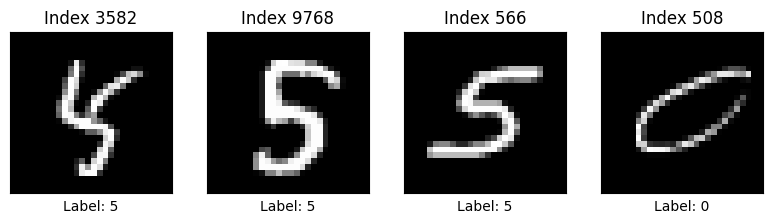

In [21]:
face_subset = face_paths.iloc[0:3]
plot_paths(np.array(X),list(y),list(face_subset['index'])+[508])

In [22]:
pca_demo_path = pca_paths.iloc[0:8]
raw_demo_path = raw_paths.iloc[0:4]
face_demo_path = face_paths.iloc[0:3]

In [23]:
split_data = {}

for paths,name in list(zip([raw_paths,pca_paths,face_paths],['raw','pca','face'])):
    print(f"{name} paths: {np.unique(paths['path_id']).shape[0]}")
    split_data[name] = {'original':paths}
    

raw paths: 100000
pca paths: 100000
face paths: 75765


In [24]:
pca_demo_path

,index,next_index,path_id,start_label,end_label
0,2456,9296,2456_5763,0,7
1,9296,3943,2456_5763,0,7
2,3943,5587,2456_5763,0,7
3,5587,9343,2456_5763,0,7
4,9343,1198,2456_5763,0,7
5,1198,7514,2456_5763,0,7
6,7514,9719,2456_5763,0,7
7,9719,5763,2456_5763,0,7


PCA DEMO


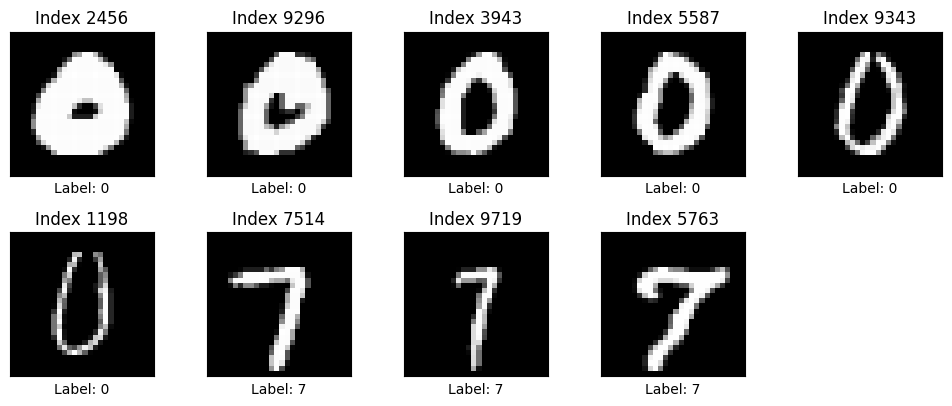

In [25]:

indices = list(pca_demo_path['index'])
final_ind = list([pca_demo_path['next_index'].iloc[-1]])

print("PCA DEMO")
plot_paths(np.array(X),list(y),indices+final_ind)


Raw demo path


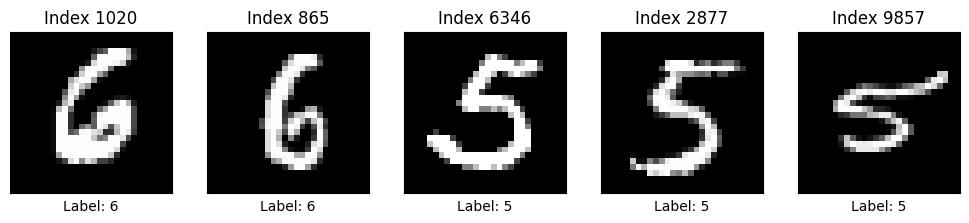

In [26]:

indices = list(raw_demo_path['index'])
final_ind = list([raw_demo_path['next_index'].iloc[-1]])
print("Raw demo path")
plot_paths(np.array(X),list(y),indices+final_ind)

FACE Demo Path


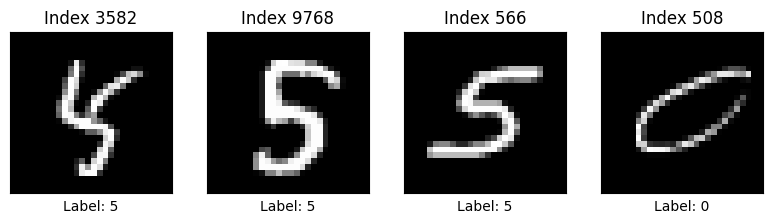

In [27]:

indices = list(face_demo_path['index'])
final_ind = list([face_demo_path['next_index'].iloc[-1]])
print("FACE Demo Path")
plot_paths(np.array(X),list(y),indices+final_ind)

In [28]:
def get_direct_paths(paths):
    direct_paths = pd.DataFrame()
    
    # Split path_id into start_id and end_id
    direct_paths[['index', 'next_index']] = paths['path_id'].str.split('_', expand=True).astype(int)
    direct_paths = direct_paths.drop_duplicates()
    return direct_paths

def get_local_paths(paths,y):
    return  paths[(y[paths['index']] != y[paths['next_index']])]
    

In [29]:
paths = {
    'raw':{'original':{'inputs':raw_paths}},
    'pca':{'original':{'inputs':pca_paths}},
    'face':{'original':{'inputs':face_paths}}
}

for path_type, path in paths.items():
    
    direct_paths = get_direct_paths(path['original']['inputs'])
    mask = direct_paths['index'].isin(X.index) & direct_paths['next_index'].isin(X.index)
    paths[path_type]['direct'] = {'inputs': direct_paths[mask]}
    print(f"{path_type} paths, Direct: {len(paths[path_type]['direct']['inputs'])}")

    local_paths = get_local_paths(path['original']['inputs'],y)
    mask = local_paths['index'].isin(X.index) & local_paths['next_index'].isin(X.index)
    paths[path_type]['local'] = {'inputs':local_paths[mask]}
    print(f"{path_type} paths, Local: {len(paths[path_type]['local']['inputs'])}")

raw paths, Direct: 2738
raw paths, Local: 5387
pca paths, Direct: 2789
pca paths, Local: 4884
face paths, Direct: 2382
face paths, Local: 19216


n_cf = 1

- raw paths, Direct: 2738
- raw paths, Local: 5387
- pca paths, Direct: 2789
- pca paths, Local: 4884
- face paths, Direct: 2382
- face paths, Local: 19216

n_cf = 3

- raw paths, Direct: 2738
- raw paths, Local: 5387
- pca paths, Direct: 2789
- pca paths, Local: 4884
- face paths, Direct: 2382
- face paths, Local: 19216

In [30]:
import pandas as pd
import numpy as np

def find_indices_with_multiple_connections(paths, y, n_cf, random_state=42):
    """
    For each unique `index` in X, find those that connect to at least n_cf unique `next_index` values.
    Randomly sample n_cf unique next_index entries and assign corresponding labels from y.

    Parameters
    ----------
    X : pd.DataFrame
        Must contain 'index' and 'next_index' columns.
    y : pd.Series or pd.DataFrame-like
        Label lookup, indexed by the same 'next_index' values as in X.
    n_cf : int
        Minimum number of unique connections required and number to sample.
    random_state : int, optional
        Seed for reproducibility.

    Returns
    -------
    pd.DataFrame
        Columns: index, next_indices (list), labels (list)
    """
    results = []

    for idx, group in paths.groupby("index"):
        # Unique next_index values for this index
        unique_next = pd.Series(group["next_index"].unique())

        # Only keep if enough unique connections
        if len(unique_next) >= n_cf:
            # Randomly sample n_cf next_index values
            subsample = unique_next.sample(n=n_cf, random_state=random_state)

            # Lookup corresponding labels from y
            labels = [y[y_idx] for y_idx in subsample]

            results.append({
                "index": idx,
                "next_indices": subsample.tolist(),
                "labels": labels
            })

    return pd.DataFrame(results)


In [31]:
test_output = find_indices_with_multiple_connections(paths['raw']['local']['inputs'],y, n_cf=n_cf) 

In [32]:
test_output

,index,next_indices,labels
0,31,"[4377, 2879]","[7, 8]"
1,104,"[1407, 3482]","[3, 3]"
2,121,"[3604, 222]","[8, 6]"
3,124,"[2663, 4453]","[1, 1]"
4,171,"[2626, 8586]","[3, 3]"
...,...,...,...
201,9596,"[8753, 6794]","[3, 3]"
202,9754,"[511, 606]","[8, 0]"
203,9891,"[4600, 1054]","[2, 3]"
204,9942,"[2523, 7190]","[9, 9]"


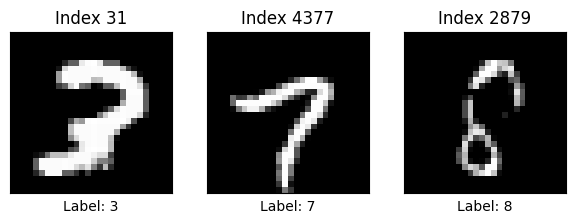

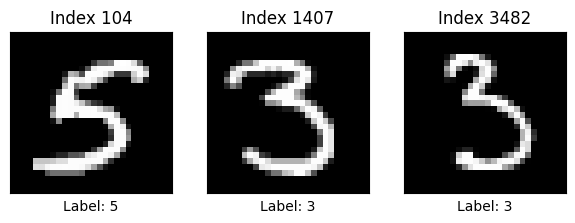

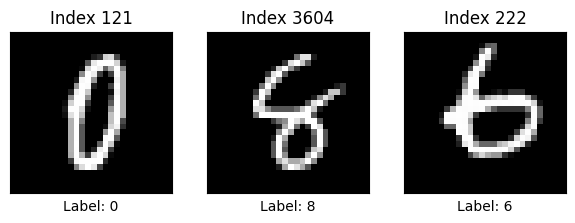

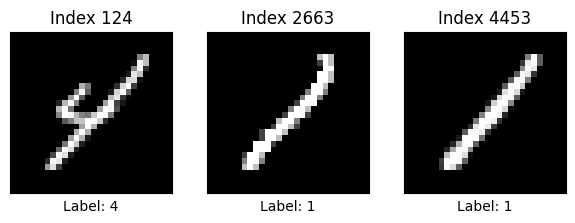

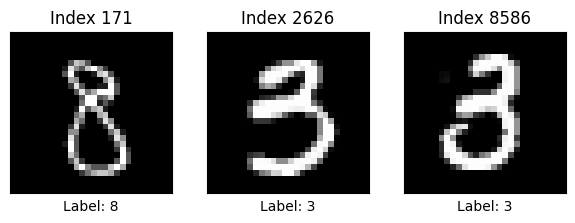

In [33]:
# plot_paths(X,y,)
plot_idx = 0
for plot_idx in [0,1,2,3,4]:
    plot_paths(np.array(X),list(y),[test_output['index'].values[plot_idx]]+test_output['next_indices'].values[plot_idx])

In [34]:
test_output = find_indices_with_multiple_connections(paths['raw']['direct']['inputs'],y, n_cf=n_cf) 

In [35]:
test_output

,index,next_indices,labels
0,16,"[2100, 4622]","[9, 5]"
1,19,"[9891, 2016]","[7, 3]"
2,24,"[6997, 1527]","[9, 3]"
3,31,"[9984, 9927]","[5, 5]"
4,36,"[3080, 1303]","[2, 6]"
...,...,...,...
805,9930,"[3911, 7552]","[6, 2]"
806,9937,"[3424, 3746]","[3, 1]"
807,9942,"[5258, 504]","[8, 5]"
808,9966,"[1915, 4531]","[6, 9]"


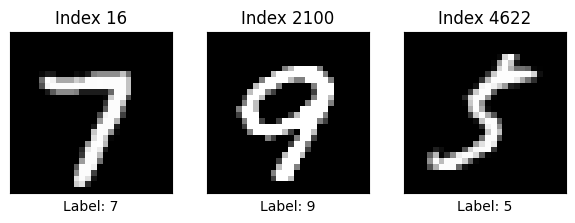

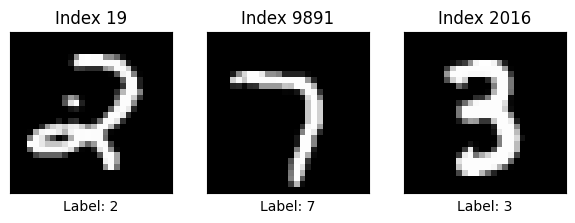

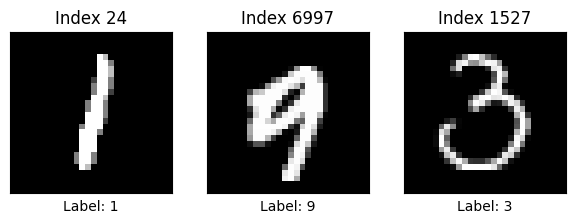

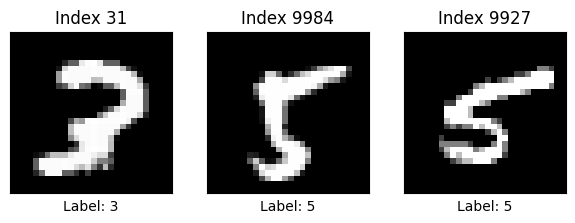

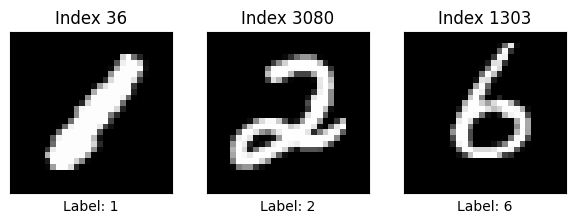

In [36]:
# plot_paths(X,y,)
plot_idx = 0
for plot_idx in [0,1,2,3,4]:
    plot_paths(np.array(X),list(y),[test_output['index'].values[plot_idx]]+test_output['next_indices'].values[plot_idx])

In [37]:
for path_type, path in paths.items():
    for path_length in ['original','direct','local']:
        paths[path_type][path_length]['outputs'] = find_indices_with_multiple_connections(
                                                        paths[path_type][path_length]['inputs'],
                                                        y,
                                                        n_cf=n_cf,
                                                        random_state=42)
        
        print(f"{path_type} | {path_length} : {len(paths[path_type][path_length]['outputs'])}")
        

raw | original : 9998
raw | direct : 810
raw | local : 206
pca | original : 9988
pca | direct : 823
pca | local : 162
face | original : 7139
face | direct : 769
face | local : 99


In [38]:

unique_sets ={}
for path_length in ['original','direct','local']:
    unique_set = set()
    for path_type, path in paths.items():    
        if len(unique_set):
            unique_set = unique_set.intersection(set(tuple(paths[path_type][path_length]['outputs']['index'])))
        else: 
            unique_set.update(tuple(paths[path_type][path_length]['outputs']['index']))
    unique_sets[path_length] = unique_set
    print(f"Path length: {path_length} | Common indices: {len(unique_set)}")
        
# for path_type, path in paths.items():
#     for path_length in ['original','direct','local']:


Path length: original | Common indices: 7129
Path length: direct | Common indices: 178
Path length: local | Common indices: 21


In [39]:
def compile_mnist(X,y,cf_X,cf_y):

    magnitude = np.ones(len(cf_X))
    magnitude = np.expand_dims(magnitude, axis=1)
    
    print(f'Returning {len(X)} samples with {len(cf_y)} counterfactuals')
    
    return {'X':np.array(X),
            'Y':list(y),
            'K':{
                'vector':cf_X,
                 'label':cf_y,
                 'magnitude':np.expand_dims(magnitude,axis=1), 
                 }}

In [40]:

for path_type, path in paths.items():
    for path_length in ['original','direct','local']:
        dataset = paths[path_type][path_length]['outputs'][paths[path_type][path_length]['outputs']['index'].isin(unique_sets[path_length])]
        
        if len(dataset) <= n_train:
            print(
                f"\n\nPath type: {path_type} | Path length: {path_length}\n"
                f"Requested dataset size ({n_train}) is greater than available data ({len(dataset)}). "
                "Reducing automatically. Try reducing n_cf or increasing X_train."
            )
            # raise UserWarning(f"Requested dataset size ({n_train}) is greater than available data, reducing to {len(dataset)}. Try reducing n_cf or incrasing X_train")
        else:
            dataset = dataset.sample(n=n_train, random_state=42)
         
        X_train_sample = np.array(X.iloc[dataset['index']])
        y_train_sample = np.array(y_df['y'].iloc[dataset['index']]).squeeze()
        
        cf_X_sample = np.array([X.iloc[i] for i in dataset['next_indices']])
        cf_y_sample = np.array([y_df['y'].iloc[i] for i in dataset['next_indices']])
        

        # Stripping html from unprocessed text, just to clean it up
        print('\ntrain_Data')
        cf_train={'original': compile_mnist(X_train_sample,y_train_sample,cf_X_sample,cf_y_sample)} # X,y,text,cf_X,cf_text

        print('\ndev_Data')
        cf_dev={'original': compile_mnist(X_dev,y_dev,
                                        np.expand_dims(np.zeros_like(X_dev),axis=1),
                                        np.expand_dims(np.zeros_like(y_dev),axis=1)
                                        )} # X,y,text,cf_X,cf_text

        print('\ntest_Data')
        cf_test={'original': compile_mnist(X_test,y_test,
                                        np.expand_dims(np.zeros_like(X_test),axis=1),
                                        np.expand_dims(np.zeros_like(y_test),axis=1)
                                        )} # X,y,text,cf_X,cf_text
        print('\ncontrol_Data')

        
        cf_X_control = cf_X_sample.reshape(cf_X_sample.shape[0]*cf_X_sample.shape[1],cf_X_sample.shape[2])
        cf_y_control = cf_y_sample.reshape(cf_y_sample.shape[0]*cf_y_sample.shape[1]) 
        X_control = np.vstack((X_train_sample, cf_X_control))
        y_control = np.hstack((y_train_sample, cf_y_control))
        
        cf_control={'original': compile_mnist(X_control,y_control,
                                        np.expand_dims(np.zeros_like(X_control),axis=1),
                                        np.expand_dims(np.zeros_like(y_control),axis=1)
                                        )} # X,y,text,cf_X,cf_text
        
        """
        ########################################################################################################################
        Save embeddings
        ########################################################################################################################
        """

        pickle_data = {'train':cf_train,'test':cf_test,'dev':cf_dev, 'control':cf_control,'n_classes': 10}

        embedding_path = f'data/integer_len{len(dataset)}__connected_{str(connected_paths)}__path_{path_type}__length_{path_length}__cfn_{n_cf}.pkl'
        print(f"Saving to {embedding_path}")
        with open(embedding_path, 'wb') as file:
            pkl.dump(pickle_data, file)

        if visualise:
            print(f"PATH TYPE: {path_type} | PATH LENGTH: {path_length}")
            sample_size = 5
            for i,K in enumerate(cf_train['original']['K']['vector'][0:sample_size]):            
                plot_paths([cf_train['original']['X'][i]],[cf_train['original']['Y'][i]],[0])
                plot_paths(K,cf_train['original']['K']['label'][i],np.arange(len(K)))


train_Data
Returning 50 samples with 50 counterfactuals

dev_Data
Returning 5000 samples with 5000 counterfactuals

test_Data
Returning 5000 samples with 5000 counterfactuals

control_Data
Returning 150 samples with 150 counterfactuals
Saving to data/integer_len50__connected_False__path_raw__length_original__cfn_2.pkl

train_Data
Returning 50 samples with 50 counterfactuals

dev_Data
Returning 5000 samples with 5000 counterfactuals

test_Data
Returning 5000 samples with 5000 counterfactuals

control_Data
Returning 150 samples with 150 counterfactuals
Saving to data/integer_len50__connected_False__path_raw__length_direct__cfn_2.pkl


Path type: raw | Path length: local
Requested dataset size (50) is greater than available data (21). Reducing automatically. Try reducing n_cf or increasing X_train.

train_Data
Returning 21 samples with 21 counterfactuals

dev_Data
Returning 5000 samples with 5000 counterfactuals

test_Data
Returning 5000 samples with 5000 counterfactuals

control_Data
Re

In [41]:
face_inds = paths['face']['original']['outputs'][paths['face']['original']['outputs']['index'].isin(unique_set)]
face_X  = np.array(X.iloc[face_inds['index']])
raw_inds = paths['raw']['original']['outputs'][paths['raw']['original']['outputs']['index'].isin(unique_set)]
raw_X  = np.array(X.iloc[raw_inds['index']])
pca_inds = paths['pca']['original']['outputs'][paths['pca']['original']['outputs']['index'].isin(unique_set)]
pca_X  = np.array(X.iloc[pca_inds['index']])


In [42]:
cf_train['original']['X'].shape

(21, 784)

In [43]:
cf_train['original']['K']['vector'].shape

(21, 2, 784)

In [46]:
paths['face']['direct']['outputs']

,index,next_indices,labels
0,12,"[4206, 7996]","[6, 5]"
1,43,"[9204, 8901]","[1, 9]"
2,53,"[6634, 7406]","[9, 0]"
3,102,"[1229, 7996]","[4, 5]"
4,104,"[4206, 6288]","[6, 2]"
...,...,...,...
764,9942,"[1983, 6288]","[9, 2]"
765,9966,"[7080, 3901]","[7, 8]"
766,9977,"[9382, 8667]","[8, 0]"
767,9984,"[7080, 4208]","[7, 2]"


In [45]:
sample_list = [10]
path_types = ['raw','pca','face']
for i,path_type in enumerate(path_types):
    print(f"PATH TYPE: {path_type}")
    dataset = paths[path_type]['direct']['outputs']
    # print(f'\n\nRow {sample_list}')
    for j,s in enumerate(sample_list):
        indices = [dataset['X'][i]] + dataset['K']['X'][i] + dataset['K']['K'][i]
        print(indices)
        
        
        plot_paths(np.array(X),list(y),indices)
        # plot_paths(np.array(X),list(y),[dataset['X'][i]])
        # plot_paths(np.array(X),list(y),dataset['K']['X'][i])
        # plot_paths(np.array(X),list(y),dataset['K']['K'][i])

PATH TYPE: raw


KeyError: 'X'